In [1]:
import pandas as pd
# Library to manipulate matrices
import numpy as np
# Plotting library 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import ipywidgets as widgets
%matplotlib inline
import plotly.express as px

In [2]:
#Loading PJM Hourly data
data=pd.read_csv("PJME_hourly.csv")

In [3]:
#Analyzing data
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
#Analysing data
data.shape

(145366, 2)

In [5]:
#Analysing data
data.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


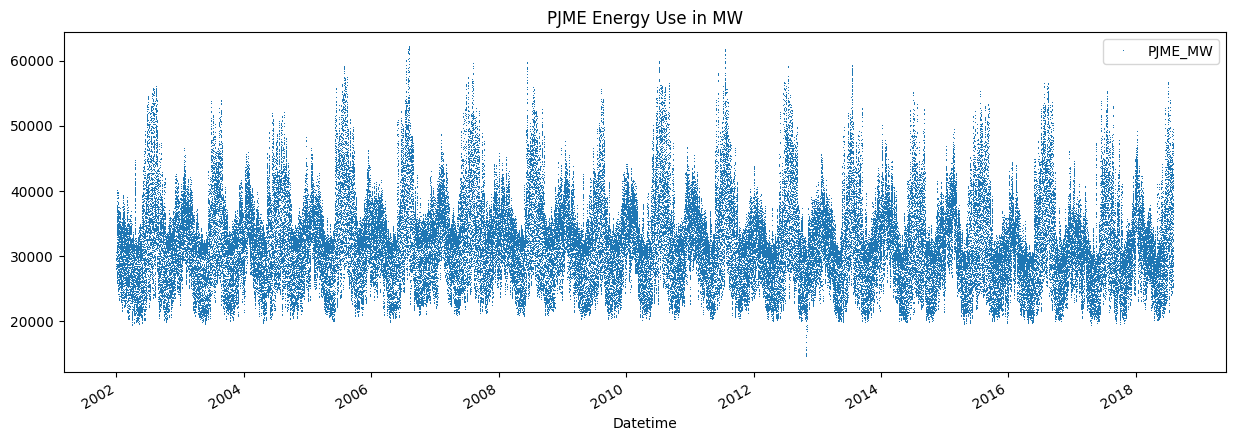

In [6]:
#Checking data types for columns
data.dtypes

#Datetime feature is object type, converting it to datetime
data["Datetime"]=pd.to_datetime(data["Datetime"])

#Setting Datetime as index to make panda operations easier
data_setindex=data.set_index("Datetime")

#Visulaizing Energy consumption as per datetime
data_setindex.plot(style=",", figsize=(15,5), title='PJME Energy Use in MW')
plt.show()
       

In [7]:
# Remove duplicate timestamps first
data_setindex = data_setindex[~data_setindex.index.duplicated(keep='first')]

# Check for missing timestamps
full_range = pd.date_range(start=data_setindex.index.min(), 
                           end=data_setindex.index.max(), freq='h')
missing = full_range.difference(data_setindex.index)
print(f"Missing timestamps: {len(missing)}")

# Reindex and impute
data_setindex = data_setindex.reindex(full_range)
data_setindex['PJME_MW'] = data_setindex['PJME_MW'].interpolate(method='time')
print(f"NaNs after imputation: {data_setindex.isna().sum().sum()}")

Missing timestamps: 30
NaNs after imputation: 0


30 missing hourly timestamps were detected in the dataset. These missing hours were not visible via `isna().sum()` as the rows were completely absent from the data.

Using `reindex()`, the missing hours were inserted as `NaN` rows to make the timeline continuous. These `NaN` values were then imputed using **time-weighted interpolation**, which estimates each missing value by considering its neighbouring previous and future data points — respecting the actual time gap between them

                     PJME_MW
2002-06-26 13:00:00  51677.0
2002-06-26 14:00:00  52637.0
2002-06-26 15:00:00  52938.0
2002-06-26 16:00:00  52894.0
2002-06-26 17:00:00  52148.0
...                      ...
2018-07-16 15:00:00  52742.0
2018-07-16 16:00:00  53408.0
2018-07-16 17:00:00  53764.0
2018-07-16 18:00:00  53352.0
2018-07-16 19:00:00  52226.0

[1320 rows x 1 columns]
1320


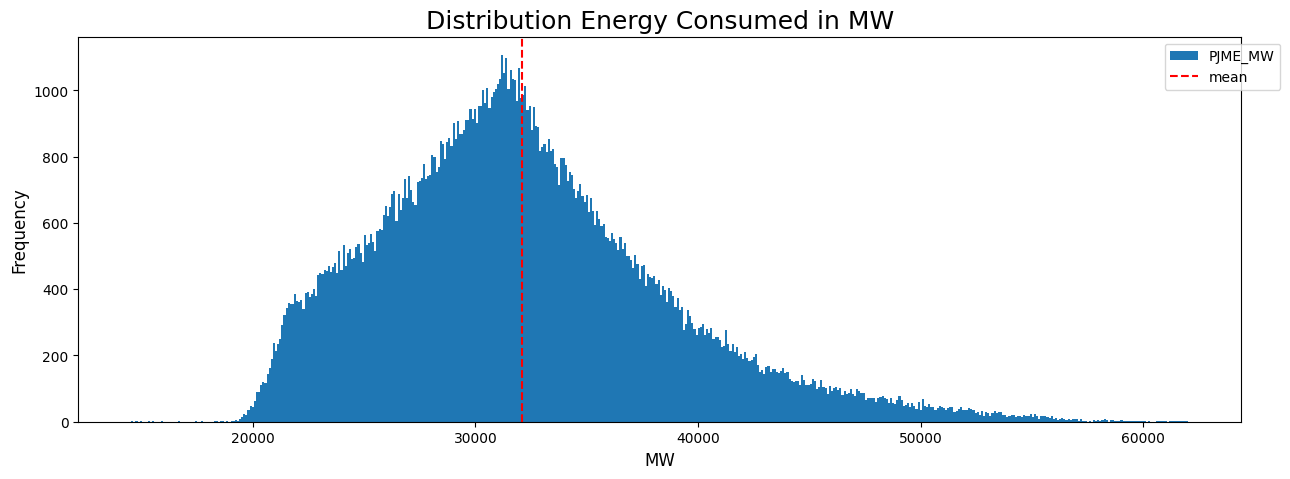

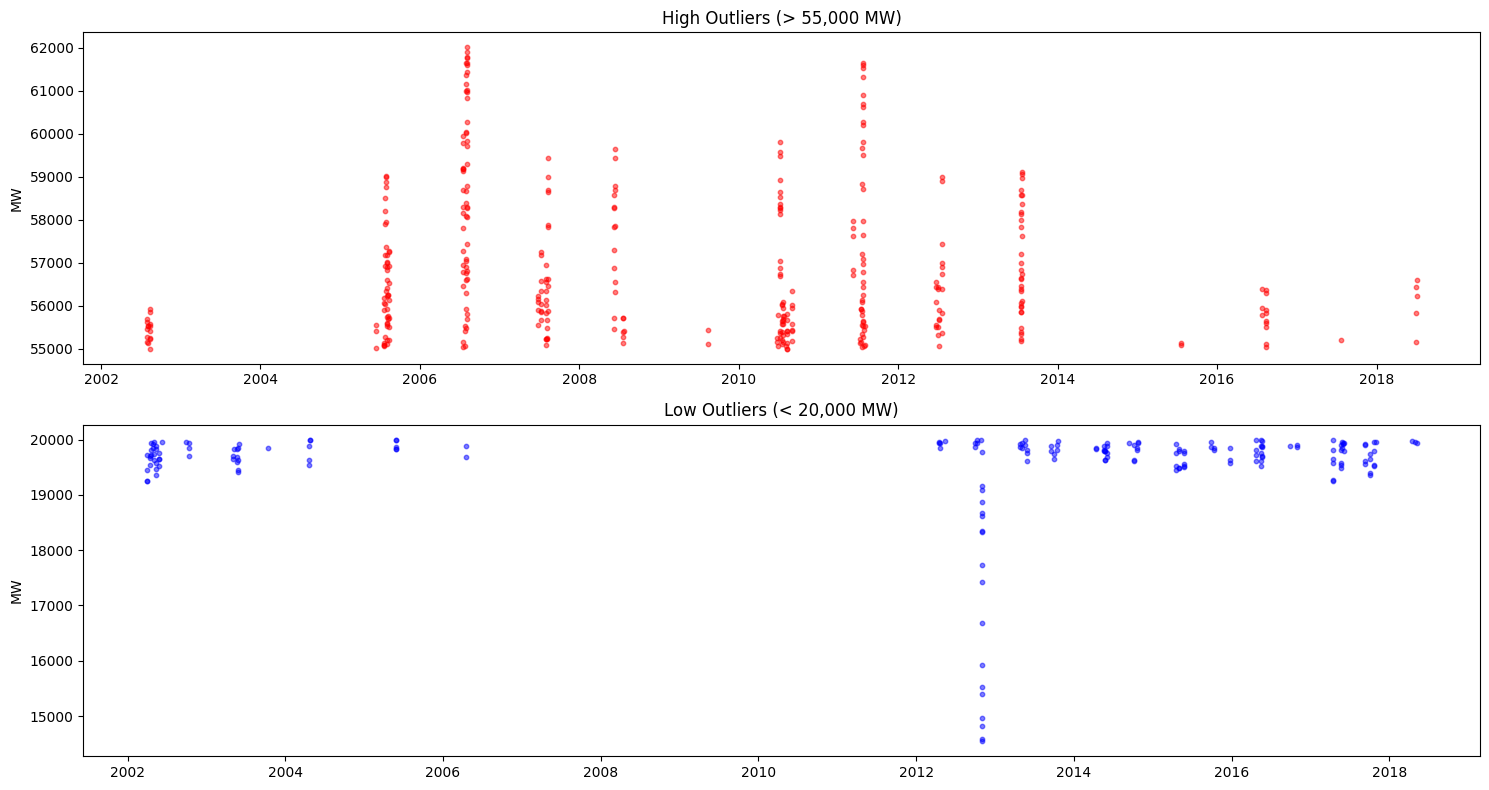

In [8]:
# Dealing with outliers

# Plot distribution of energy consumption to visually inspect spread and skewness
mean_MW = data_setindex['PJME_MW'].mean()
data_setindex['PJME_MW'].plot(figsize=(15,5), kind='hist', bins=500)
plt.title('Distribution Energy Consumed in MW', fontsize=18)
plt.xlabel('MW', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=mean_MW, color='r', linestyle='--', label='mean')
plt.legend(bbox_to_anchor=(1.04,1))

# Z-score measures how many standard deviations a value is from the mean
# Values with |z| > 3 are considered statistical outliers
z = np.abs((data_setindex['PJME_MW'] - data_setindex['PJME_MW'].mean()) / data_setindex['PJME_MW'].std())

# Filter and inspect outliers
outliers_z_score = data_setindex[z > 3]
print(outliers_z_score)
print(len(outliers_z_score))

# Separate outliers into high and low to understand their nature
high_outliers = data_setindex.query('PJME_MW > 55000')
low_outliers  = data_setindex.query('PJME_MW < 20000')

# Scatter plot to identify when outliers occur across the timeline
# High outliers recurring every summer suggest heatwave events
# Low outliers with an isolated extreme dip around 2012 suggest Hurricane Sandy
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].scatter(high_outliers.index, high_outliers['PJME_MW'],
                color='red', alpha=0.5, s=10)
axes[0].set_title('High Outliers (> 55,000 MW)')
axes[0].set_ylabel('MW')

axes[1].scatter(low_outliers.index, low_outliers['PJME_MW'],
                color='blue', alpha=0.5, s=10)
axes[1].set_title('Low Outliers (< 20,000 MW)')
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.show()

# Remove Hurricane Sandy extreme dip — isolated infrastructure failure, not real demand
data_setindex = data_setindex[data_setindex['PJME_MW'] > 19000]

1,318 observations have Z-scores greater than 3, representing just 0.91% of the 145,366 total readings. As visualised in the scatter plots above, high outliers (above 55,000 MW) recur consistently every summer across the full 2002-2018 period, confirming these are genuine heatwave-driven demand spikes and are therefore retained. Low outliers however reveal two distinct behaviours: the majority of low values around 19,000-20,000 MW recur consistently across all years representing natural low demand periods and are retained, whilst an isolated extreme dip to ~14,544 MW in October 2012, observed nowhere else in the dataset, coincides precisely with Hurricane Sandy making landfall in the PJM East region, representing infrastructure failure rather than real demand and is therefore removed by filtering values below 19,000 MW. RobustScaler is selected for scaling as it is resistant to the retained outliers, unlike StandardScaler which would be skewed by the extreme summer peak values.

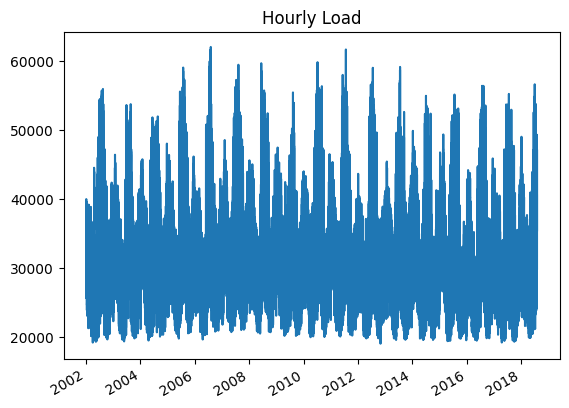

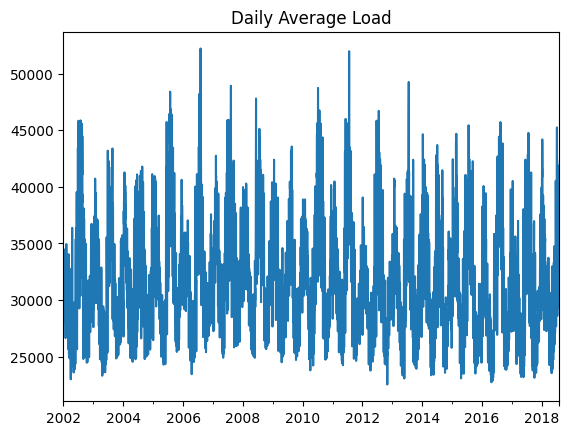

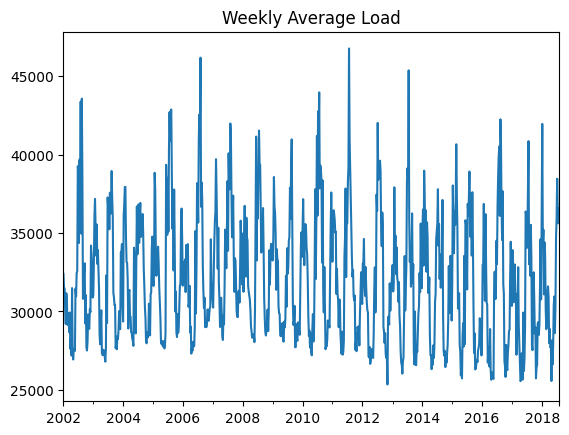

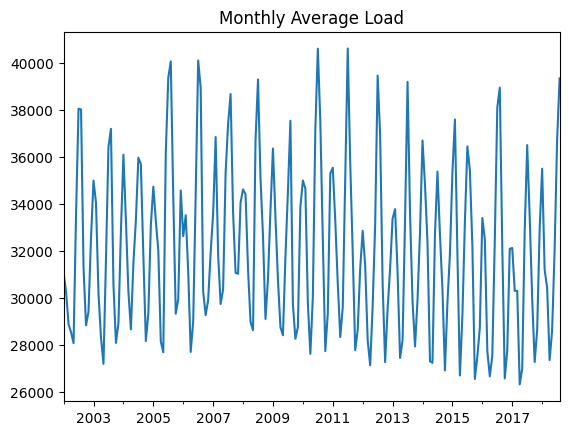

In [9]:
# Data is already at hourly frequency. Resampling is performed to analyze the data
# at different time scales (daily, weekly, monthly) using mean aggregation.

data_daily = data_setindex.resample("D").mean()
data_weekly = data_setindex.resample("W").mean()
data_monthly = data_setindex.resample("M").mean()

# Hourly
plt.figure()
data_setindex['PJME_MW'].plot(title="Hourly Load")

# Daily
plt.figure()
data_daily['PJME_MW'].plot(title="Daily Average Load")

# Weekly
plt.figure()
data_weekly['PJME_MW'].plot(title="Weekly Average Load")

# Monthly
plt.figure()
data_monthly['PJME_MW'].plot(title="Monthly Average Load")

plt.show()

The plots show that hourly data contains the most detailed information, including strong daily patterns and short term fluctuations, while daily, weekly, and monthly resampling progressively smooths the data and highlights broader trends but removes important temporal detail. Since electricity demand is highly influenced by hourly variations, especially daily cycles, using hourly data preserves the most relevant information for accurate forecasting. Therefore, hourly data is selected for modeling, while the resampled daily, weekly, and monthly data are used for exploratory analysis and understanding overall trends.

In [10]:
#Feature Engineering

import holidays

data_raw = data_setindex.copy()
data_featured = data_raw.copy()

# ── 1. Temporal ───────────────────────────────────────────────────────────────
data_featured['hour']        = data_featured.index.hour
data_featured['day_of_week'] = data_featured.index.dayofweek
data_featured['quarter']     = data_featured.index.quarter
data_featured['week']        = data_featured.index.isocalendar().week.values.astype(int)
data_featured['month']       = data_featured.index.month
data_featured['year']        = data_featured.index.year
data_featured['dayofyear']   = data_featured.index.dayofyear

# ── 2. Cyclical Encoding ──────────────────────────────────────────────────────
data_featured['hour_sin']  = np.sin(2 * np.pi * data_featured['hour'] / 24)
data_featured['hour_cos']  = np.cos(2 * np.pi * data_featured['hour'] / 24)
data_featured['month_sin'] = np.sin(2 * np.pi * data_featured['month'] / 12)
data_featured['month_cos'] = np.cos(2 * np.pi * data_featured['month'] / 12)

# ── 3. Holidays ───────────────────────────────────────────────────────────────
us_holidays = holidays.US()
data_featured['is_holiday']      = data_featured.index.normalize().map(
                                    lambda x: 1 if x in us_holidays else 0)
data_featured['days_to_holiday'] = data_featured.index.map(
                                    lambda x: min(abs((x.date() - h).days) 
                                    for h in us_holidays))

# ── 4. Statistical ────────────────────────────────────────────────────────────
data_featured['ma_7d']       = data_featured['PJME_MW'].rolling(window=7*24).mean()
data_featured['ma_30d']      = data_featured['PJME_MW'].rolling(window=30*24).mean()
data_featured['ma_90d']      = data_featured['PJME_MW'].rolling(window=90*24).mean()
data_featured['roll_std_7d'] = data_featured['PJME_MW'].rolling(window=7*24).std()
data_featured['roll_min_7d'] = data_featured['PJME_MW'].rolling(window=7*24).min()
data_featured['roll_max_7d'] = data_featured['PJME_MW'].rolling(window=7*24).max()
data_featured['ewma_7d']     = data_featured['PJME_MW'].ewm(span=7*24).mean()
data_featured['ewma_30d']    = data_featured['PJME_MW'].ewm(span=30*24).mean()
data_featured['diff_24h']    = data_featured['PJME_MW'].diff(24)
data_featured['diff_168h']   = data_featured['PJME_MW'].diff(168)

# ── 5. Lag Features ───────────────────────────────────────────────────────────
data_featured['lag_1h']   = data_featured['PJME_MW'].shift(1)
data_featured['lag_24h']  = data_featured['PJME_MW'].shift(24)
data_featured['lag_168h'] = data_featured['PJME_MW'].shift(168)

# ── 6. Domain Specific (external data not available) ─────────────────────────
# Temperature and daylight hours require external weather data — skipped

# ── Drop NaNs ─────────────────────────────────────────────────────────────────
data_featured.dropna(inplace=True)
print(f"Shape: {data_featured.shape}")
print(f"Features: {data_featured.columns.tolist()}")

print(f"Shape: {data_raw.shape}")
print(f"Features: {data_raw.columns.tolist()}")

Shape: (143218, 27)
Features: ['PJME_MW', 'hour', 'day_of_week', 'quarter', 'week', 'month', 'year', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'days_to_holiday', 'ma_7d', 'ma_30d', 'ma_90d', 'roll_std_7d', 'roll_min_7d', 'roll_max_7d', 'ewma_7d', 'ewma_30d', 'diff_24h', 'diff_168h', 'lag_1h', 'lag_24h', 'lag_168h']
Shape: (145377, 1)
Features: ['PJME_MW']


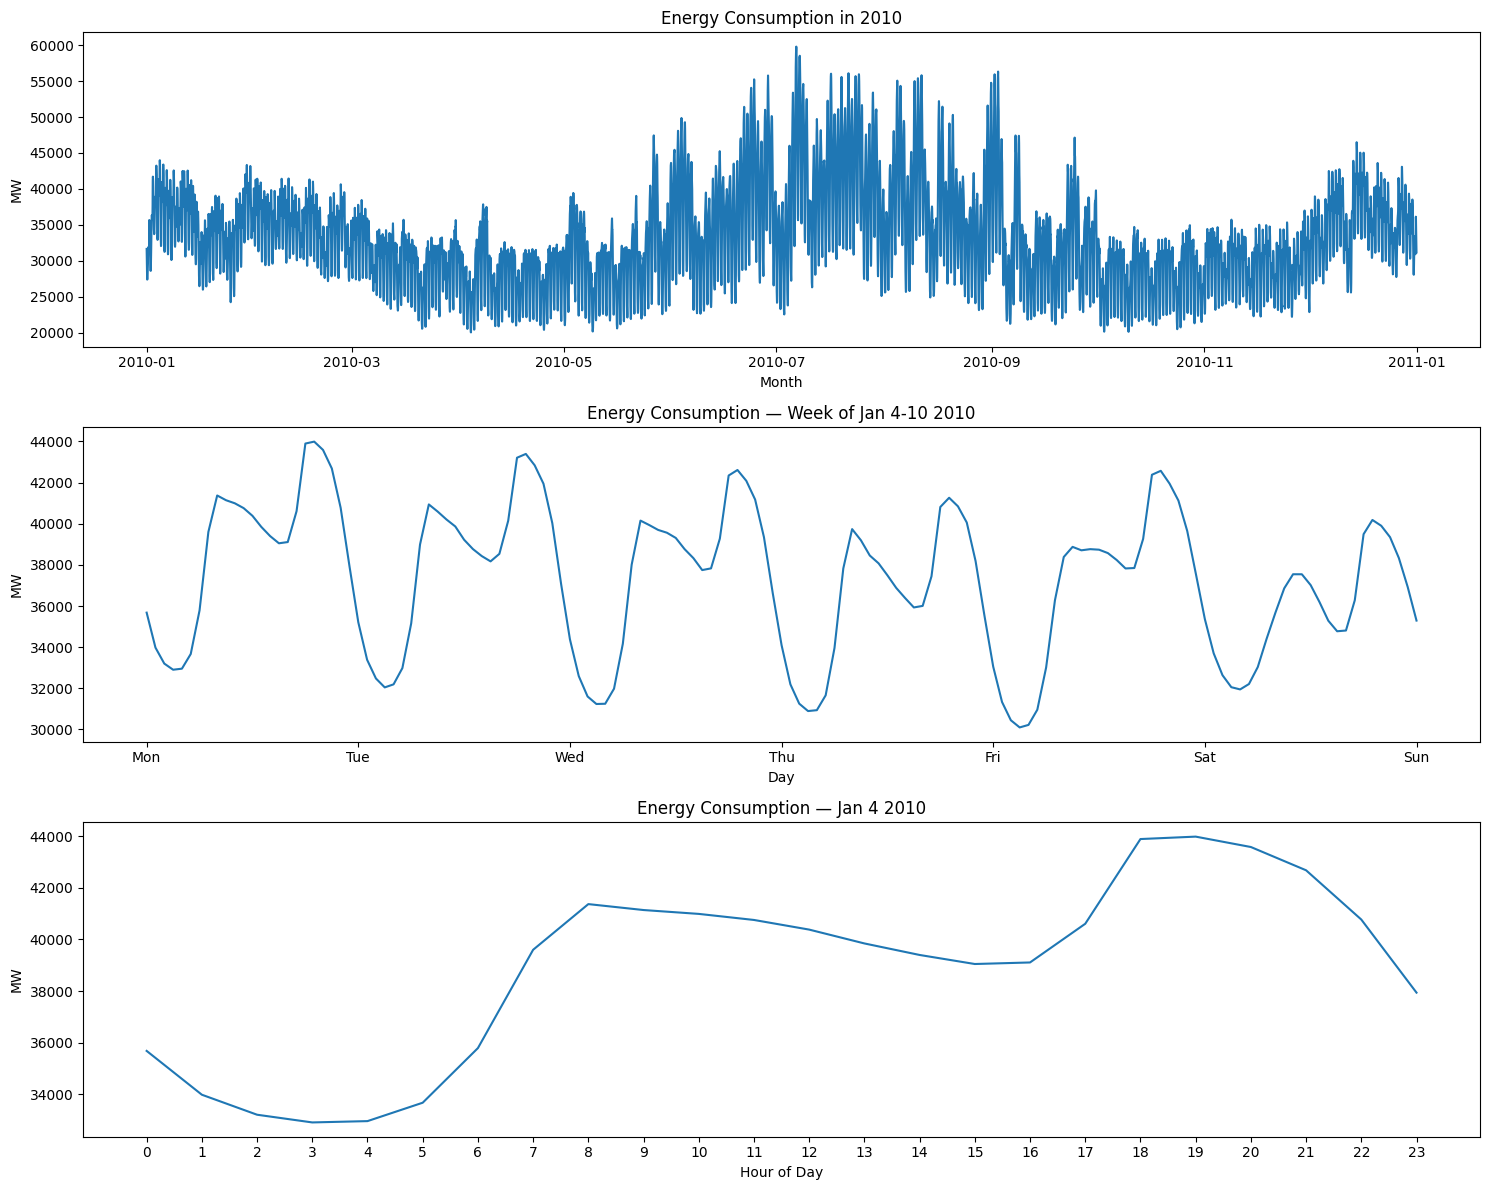

In [11]:
# Plotting energy consumption against year, week and day to observe patterns
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Full year — to observe monthly pattern
axes[0].plot(data_featured[data_featured.index.year == 2010]['PJME_MW'])
axes[0].set_title('Energy Consumption in 2010')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MW')

# One week — to observe daily pattern
week_data = data_featured[(data_featured.index >= '2010-01-04') & 
                           (data_featured.index <= '2010-01-10')]
axes[1].plot(week_data.index, week_data['PJME_MW'])
axes[1].set_title('Energy Consumption — Week of Jan 4-10 2010')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('MW')
axes[1].set_xticks(pd.date_range('2010-01-04', '2010-01-10', freq='D'))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# One day — to observe hourly pattern
day_data = data_featured[data_featured.index.date == pd.Timestamp('2010-01-04').date()]
axes[2].plot(day_data.index.hour, day_data['PJME_MW'])
axes[2].set_title('Energy Consumption — Jan 4 2010')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('MW')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

The three plots above visualise energy consumption patterns at different time scales. The yearly plot (2010) reveals a clear seasonal pattern — consumption peaks during June, July and August, likely driven by air conditioning and other cooling systems during summer heat, with a secondary smaller peak during winter months (November-January) attributable to heating demand. The lowest consumption periods occur during spring and autumn when temperatures are mild and neither heating nor cooling is heavily required. The weekly plot shows a repeating daily cycle across the 7 days, with noticeable dips during weekends (Jan 9-10) compared to weekdays, reflecting reduced industrial and commercial activity. The daily plot (Jan 4 2010) reveals a clear hourly pattern — consumption is lowest in the early morning hours (around 3-4am), rises sharply as the working day begins, peaks in the afternoon and early evening, then gradually declines overnight. These patterns confirm that energy consumption is strongly influenced by time of day, day of week and month of year, justifying the temporal features engineered in the previous section.

                 Spearman Correlation
is_holiday                   0.029844
month_cos                    0.048376
month_sin                    0.050869
dayofyear                    0.067666
month                        0.068156
week                         0.068346
year                         0.076218
quarter                      0.078621
days_to_holiday              0.085816
ma_90d                       0.093328
day_of_week                  0.192467
diff_24h                     0.221309
diff_168h                    0.282120
hour_cos                     0.302218
roll_std_7d                  0.318450
ma_30d                       0.464961
hour_sin                     0.474189
roll_min_7d                  0.478115
ewma_30d                     0.492235
hour                         0.514107
roll_max_7d                  0.514279
ma_7d                        0.546224
ewma_7d                      0.588197
lag_168h                     0.802420
lag_24h                      0.880315
lag_1h      

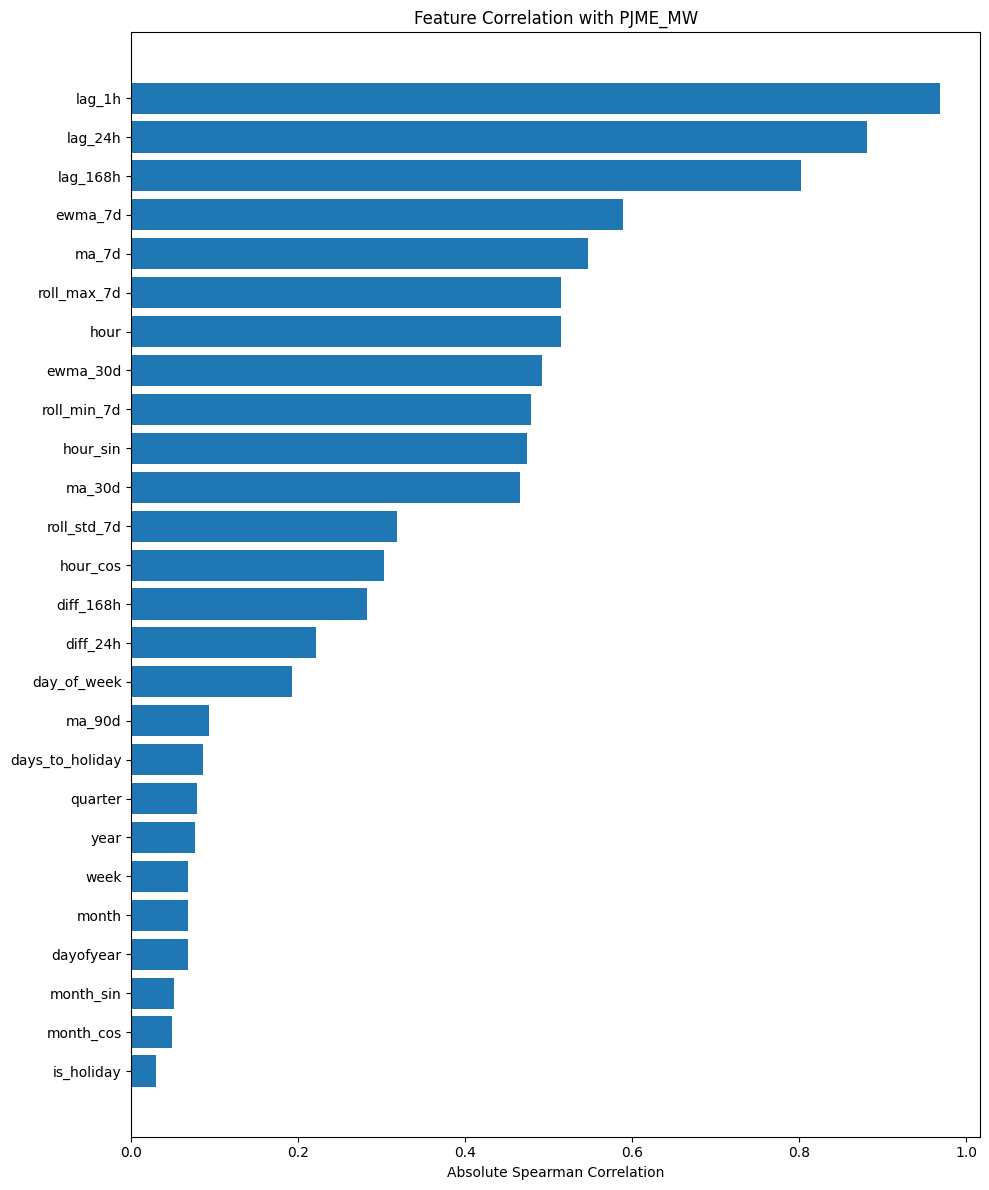

In [12]:
# Feature selection is performed using three methods:
# 1) Filter method (Spearman correlation) — measures the statistical relationship 
#    between each feature and the target variable, independent of any model.
# 2) Wrapper method (RFE) — applied after model selection, RFE iteratively removes 
#    the least important features and evaluates model performance on each subset.
# 3) Embedded method — utilises the built-in feature importance of Linear Regression 
#    (coefficients) and XGBoost (gain-based importance), which are learned during 
#    training. Results from all three methods will later be compared to identify the most 
#    consistently important features.

# Feature Selection using Spearman Correlation
from scipy.stats import spearmanr

# Calculate Spearman correlation of each feature with target
correlations = {}
for col in data_featured.columns:
    if col != 'PJME_MW':
        corr, _ = spearmanr(data_featured['PJME_MW'], data_featured[col])
        correlations[col] = corr

# Convert to dataframe and sort by absolute correlation
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Spearman Correlation'])
corr_df = corr_df.abs().sort_values('Spearman Correlation', ascending=True)

# Print all coefficients
print(corr_df.to_string())

# Bar chart of all correlations
plt.figure(figsize=(10, 12))
plt.barh(corr_df.index, corr_df['Spearman Correlation'])
plt.xlabel('Absolute Spearman Correlation')
plt.title('Feature Correlation with PJME_MW')
plt.tight_layout()
plt.show()


As observed in the bar chart above, lag features exhibit the highest Spearman correlation with PJME_MW, which is expected as previous consumption values are the strongest indicator of future demand. lag_1h shows the highest correlation, as the most recent hour is the most direct indicator of the next, followed by lag_24h and lag_168h representing 1 day and 1 week prior respectively. Statistical features such as ewma_7d, ma_7d and roll_max_7d follow, capturing short-term trends in consumption. Temporal features such as hour and day_of_week show moderate correlation, whilst cyclical encodings (month_sin, month_cos, dow_cos) and is_holiday show near-zero Spearman coefficients. This does not imply these features are uninformative, rather it reflects a fundamental limitation of Spearman's correlation, which only measures monotonic relationships where values consistently increase or decrease together. Cyclical features such as month_sin and month_cos follow a sine wave pattern where the first and last values are close together, meaning the relationship with the target is not monotonic but circular. Spearman cannot capture this circular structure, causing it to underestimate the true importance of these features despite the clear seasonal patterns observed in the plots above.

Fold 1 — Train: 99394, Val: 8760
Fold 2 — Train: 108154, Val: 8760
Fold 3 — Train: 116914, Val: 8760
Fold 4 — Train: 125674, Val: 8760
Fold 5 — Train: 134434, Val: 8760


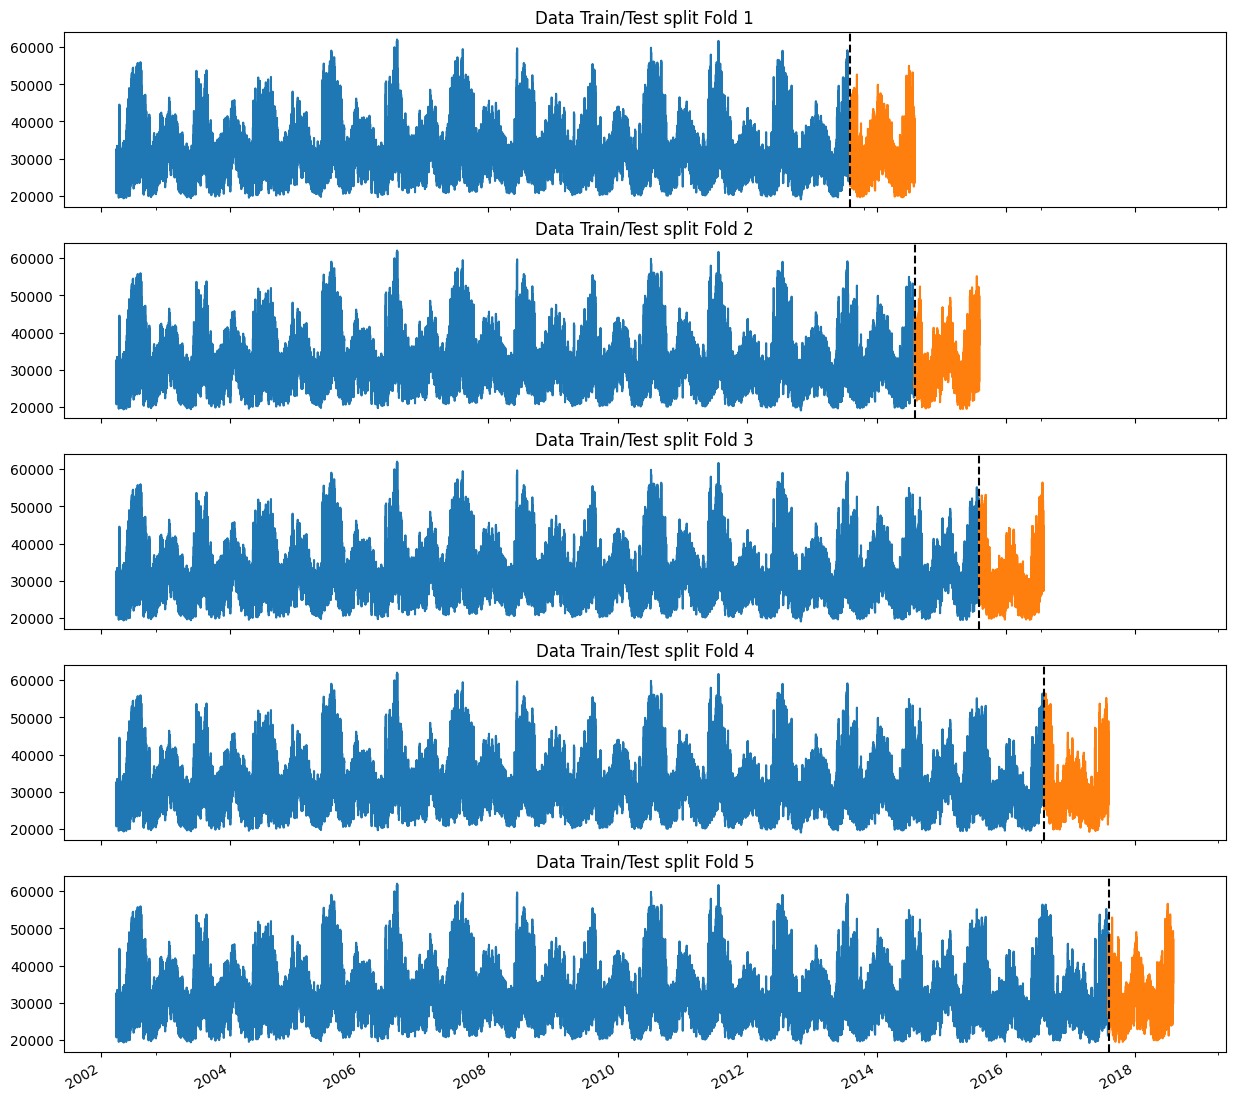

In [13]:
#Time Based Cross Validation
from sklearn.model_selection import TimeSeriesSplit

cv_data = data_featured

X = cv_data.drop(columns=['PJME_MW'])
y = cv_data['PJME_MW']

# Now run cross validation on cv_data only
tss = TimeSeriesSplit(
    n_splits=5,
    gap=24,          # 1 day
    test_size=8760   # 1 year
)

#Each fold keeps all previous training data and adds more — the window expands forward in time.
fig, axs = plt.subplots(5, 1,figsize = (15,15), sharex=True)

fold = 0

for fold, (train_index, val_index) in enumerate(tss.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    train =cv_data.iloc[train_index]
    test = cv_data.iloc[val_index]
    train['PJME_MW'].plot(ax = axs[fold],
                         label = 'Training Set',
                         title = f'Data Train/Test split Fold {fold+1}')
    test['PJME_MW'].plot(ax = axs[fold], label = 'Test Set')
    
    axs[fold].axvline(test.index.min(), color = 'black', ls = '--')
    print(f"Fold {fold+1} — Train: {len(X_train)}, Val: {len(X_val)}")

#As a means of scaling, RobustScaler is selected because it is resistant to outliers unlike other scaling methods such as StandardScaler
#which is sensitive to extreme values through its use of mean and standard deviation.
  
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)